#### Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder,StandardScaler

#### Import Dataset

In [28]:
dataset=pd.read_csv("geocoded_data_complete.csv")

In [3]:
dataset.head() ##preview top five data records

,Parking,Flooring,Laundry,Dishwasher,Stainless_Appliances,Cable,Internet,Outdoor_Spaces,AC,Pool,...,State,City,rental_type,Price,Unit_Type,Bedrooms,city_clean,state_clean,latitude,longitude
0,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,DC,Washington,Monthly,940.0,studio,0,washington,dc,38.912217,-77.017691
1,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,IN,Evansville,Monthly,425.0,studio,0,evansville,in,37.974600,-87.567400
2,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,IN,Evansville,Monthly,445.0,1 bedroom,1,evansville,in,37.974600,-87.567400
3,not,other,not,not,not,not,not,Combined,not,not,...,VA,Arlington,Monthly,1390.0,studio,0,arlington,va,38.887103,-77.093197
4,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,WA,Seattle,Monthly,925.0,studio,0,seattle,wa,47.611435,-122.330456


In [4]:
dataset.shape ###shape of the dataset

(12376, 21)

In [5]:
dataset.info() ##overoll information of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12376 entries, 0 to 12375
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Parking               12376 non-null  object 
 1   Flooring              12376 non-null  object 
 2   Laundry               12376 non-null  object 
 3   Dishwasher            12376 non-null  object 
 4   Stainless_Appliances  12376 non-null  object 
 5   Cable                 12376 non-null  object 
 6   Internet              12376 non-null  object 
 7   Outdoor_Spaces        12376 non-null  object 
 8   AC                    12376 non-null  object 
 9   Pool                  12359 non-null  object 
 10  Fitness_Facilities    12359 non-null  object 
 11  State                 12376 non-null  object 
 12  City                  12373 non-null  object 
 13  rental_type           12376 non-null  object 
 14  Price                 12376 non-null  float64
 15  Unit_Type          

In [6]:
dataset['Bedrooms'] = dataset['Bedrooms'].astype('object') #since variable Bedroom has 6 catogories 0,1,2,3,4,5

In [7]:
dataset.info() ##overoll information of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12376 entries, 0 to 12375
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Parking               12376 non-null  object 
 1   Flooring              12376 non-null  object 
 2   Laundry               12376 non-null  object 
 3   Dishwasher            12376 non-null  object 
 4   Stainless_Appliances  12376 non-null  object 
 5   Cable                 12376 non-null  object 
 6   Internet              12376 non-null  object 
 7   Outdoor_Spaces        12376 non-null  object 
 8   AC                    12376 non-null  object 
 9   Pool                  12359 non-null  object 
 10  Fitness_Facilities    12359 non-null  object 
 11  State                 12376 non-null  object 
 12  City                  12373 non-null  object 
 13  rental_type           12376 non-null  object 
 14  Price                 12376 non-null  float64
 15  Unit_Type          

#### Checking for Missing values

In [8]:
dataset.isnull().sum()

Parking                  0
Flooring                 0
Laundry                  0
Dishwasher               0
Stainless_Appliances     0
Cable                    0
Internet                 0
Outdoor_Spaces           0
AC                       0
Pool                    17
Fitness_Facilities      17
State                    0
City                     3
rental_type              0
Price                    0
Unit_Type                0
Bedrooms                 0
city_clean               3
state_clean              0
latitude                28
longitude               28
dtype: int64

##### missing rate is tiny (<0.03%). Therefore we dropped the missing values in the data set.

In [9]:
dataset.dropna(inplace=True)

#### Duplicate Records

In [10]:
dataset.duplicated().sum()

np.int64(481)

##### 3.9% from the dataset

In [11]:
### view duplicated rows 
dataset[dataset.duplicated()]

,Parking,Flooring,Laundry,Dishwasher,Stainless_Appliances,Cable,Internet,Outdoor_Spaces,AC,Pool,...,State,City,rental_type,Price,Unit_Type,Bedrooms,city_clean,state_clean,latitude,longitude
14,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,DC,Washington,Monthly,1090.0,studio,0,washington,dc,38.912217,-77.017691
204,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,IL,Chicago,Monthly,1095.0,studio,0,chicago,il,41.885847,-87.618123
216,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,WA,Seattle,Monthly,1195.0,studio,0,seattle,wa,47.611435,-122.330456
250,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,OR,Portland,Monthly,1099.0,studio,0,portland,or,45.442919,-122.615092
362,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,WA,Seattle,Monthly,1299.0,studio,0,seattle,wa,47.611435,-122.330456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12091,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,FL,St. Cloud,Monthly,1895.0,4 bedroom,4,st. cloud,fl,28.249853,-81.283904
12124,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,NC,Charlotte,Monthly,1399.0,3 bedroom,3,charlotte,nc,35.226900,-80.843300
12148,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,IN,Bloomington,Monthly,4800.0,5 bedroom,5,bloomington,in,39.140057,-86.508262
12193,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,WA,Seattle,Monthly,3095.0,3 bedroom,3,seattle,wa,47.611435,-122.330456


In [12]:
### Remove duplicates 
dataset = dataset.drop_duplicates()

#### categorizing the Price variable

In [13]:
quantiles = dataset['Price'].quantile([0.25, 0.5, 0.75]) 
quantiles

0.25     975.0
0.50    1325.0
0.75    1750.0
Name: Price, dtype: float64

#### Price categories

##### 975> - low range - 1
##### 1325.0> - mid range - 2
##### 1750.0> - high range - 3
##### 1750.0< - premium or luxurious - 4

In [14]:
dataset['Price_Category'] = pd.cut(
    dataset['Price'],
    bins=[0, 975, 1325, 1750, float('inf')],   # bin edges
    labels=[0, 1, 2, 3],                       # category labels
    right=False                                # include left edge, exclude right
)

# Convert category type to integer
dataset['Price_Category'] = dataset['Price_Category'].astype(int)


In [15]:
dataset.drop(['City', 'State','city_clean','state_clean','Price'], axis=1, inplace=True)

In [16]:
dataset.head()    #updated dataset

,Parking,Flooring,Laundry,Dishwasher,Stainless_Appliances,Cable,Internet,Outdoor_Spaces,AC,Pool,Fitness_Facilities,rental_type,Unit_Type,Bedrooms,latitude,longitude,Price_Category
0,not,other,not,not,not,not,not,No Outdoor Space,not,not,not,Monthly,studio,0,38.912217,-77.017691,0
1,not,other,not,not,not,not,not,No Outdoor Space,not,not,not,Monthly,studio,0,37.974600,-87.567400,0
2,not,other,not,not,not,not,not,No Outdoor Space,not,not,not,Monthly,1 bedroom,1,37.974600,-87.567400,0
3,not,other,not,not,not,not,not,Combined,not,not,not,Monthly,studio,0,38.887103,-77.093197,2
4,not,other,not,not,not,not,not,No Outdoor Space,not,not,not,Monthly,studio,0,47.611435,-122.330456,0


#### Split the Dataset into Training and Testing

In [17]:
X=dataset.drop(columns=['Price_Category'],axis=1)
Y=dataset['Price_Category']

In [18]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=42)

In [19]:
print(f"Shape of the Training set:{X_train.shape,Y_train.shape}")
print(f"Shape of  the Testgin set:{X_test.shape,Y_test.shape}")

Shape of the Training set:((8290, 16), (8290,))
Shape of  the Testgin set:((3554, 16), (3554,))


#### Response variable distribution in train data

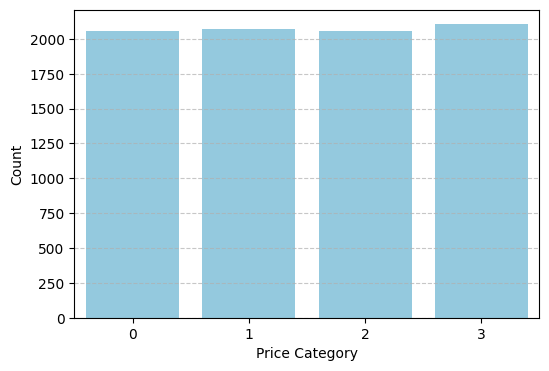

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x=Y_train, color='skyblue')
plt.xlabel('Price Category')   
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Checking for association between variables

In [21]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))


categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

cramers_v_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            cramers_v_matrix.loc[col1, col2] = cramers_v(X_train[col1], X_train[col2])

cramers_v_matrix = cramers_v_matrix.astype(float)

print(" Cramér’s V Association Matrix:\n")
print(cramers_v_matrix.round(3))

threshold = 0.6
strong_pairs = []

for i, col1 in enumerate(categorical_cols):
    for j, col2 in enumerate(categorical_cols):
        if j > i:  # avoid duplicate pairs
            val = cramers_v_matrix.loc[col1, col2]
            if val >= threshold:
                strong_pairs.append((col1, col2, val))

print("\n Strong Associations (Cramér’s V ≥ 0.6):")
if strong_pairs:
    for col1, col2, val in strong_pairs:
        print(f"  {col1} ↔ {col2} : {val:.3f}")
else:
    print("  None found above the threshold.")


 Cramér’s V Association Matrix:

                      Parking  Flooring  Laundry  Dishwasher  \
Parking                 1.000     0.367    0.525       0.505   
Flooring                0.367     1.000    0.565       0.484   
Laundry                 0.525     0.565    1.000       0.800   
Dishwasher              0.505     0.484    0.800       1.000   
Stainless_Appliances    0.026     0.140    0.059       0.089   
Cable                   0.028     0.107    0.139       0.131   
Internet                0.102     0.154    0.206       0.212   
Outdoor_Spaces          0.385     0.175    0.478       0.537   
AC                      0.427     0.448    0.566       0.594   
Pool                    0.122     0.108    0.237       0.198   
Fitness_Facilities      0.399     0.276    0.578       0.560   
rental_type             0.028     0.080    0.023       0.031   
Unit_Type               0.054     0.047    0.075       0.078   
Bedrooms                0.054     0.047    0.075       0.078   

      

##### since there is a perfect association between Unit type and Bedrooms we drop the variable Unit type

In [22]:
X_train.drop('Unit_Type', axis=1, inplace=True)
X_test.drop('Unit_Type', axis=1, inplace=True)

#### encoding categorical variables

In [23]:
X_train_encoded = pd.get_dummies(X_train, drop_first=False)
X_test_encoded = pd.get_dummies(X_test, drop_first=False)

# Align columns (to avoid mismatched dummies)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)


## Model Fitting

#### Multinomial Logistic, Random Forest, SVM, Xgboost

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier


models = {
    "Multinomial Logistic Regression": LogisticRegression(
        multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42
    ),
    "XGBoost": XGBClassifier(
        objective='multi:softmax',
        num_class=len(np.unique(Y_train)),
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=42
    ),
    "SVM": SVC(
        kernel='rbf', decision_function_shape='ovr', random_state=42
    )
}

# Fit all models
for name, model in models.items():
    model.fit(X_train_encoded, Y_train)
    print(f"✅ {name} model fitted successfully.")

# Optional: Make predictions
predictions = {name: model.predict(X_train_encoded) for name, model in models.items()}


C:\Users\LUXAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\LUXAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


✅ Multinomial Logistic Regression model fitted successfully.
✅ Random Forest model fitted successfully.


C:\Users\LUXAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:40:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost model fitted successfully.
✅ SVM model fitted successfully.


#### evaluation for train data

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


for name, model in models.items():
    # Fit
    model.fit(X_train_encoded, Y_train)
    
    # Predict on training data
    y_pred = model.predict(X_train_encoded)
    
    # Evaluate
    acc = accuracy_score(Y_train, y_pred)
    print(f"\n===== {name} =====")
    print(f"Accuracy on Training Set: {acc:.3f}")
    print("\nClassification Report:")
    print(classification_report(Y_train, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(Y_train, y_pred))


C:\Users\LUXAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\LUXAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



===== Multinomial Logistic Regression =====
Accuracy on Training Set: 0.422

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.58      0.52      2056
           1       0.35      0.34      0.34      2070
           2       0.39      0.19      0.25      2060
           3       0.45      0.58      0.51      2104

    accuracy                           0.42      8290
   macro avg       0.41      0.42      0.40      8290
weighted avg       0.41      0.42      0.40      8290

Confusion Matrix:
[[1193  464  118  281]
 [ 644  700  236  490]
 [ 437  506  387  730]
 [ 289  356  241 1218]]

===== Random Forest =====
Accuracy on Training Set: 0.865

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.91      2056
           1       0.83      0.82      0.82      2070
           2       0.83      0.84      0.83      2060
           3       0.91      0.88      0.90      2104

C:\Users\LUXAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:41:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



===== XGBoost =====
Accuracy on Training Set: 0.765

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.88      0.83      2056
           1       0.72      0.66      0.69      2070
           2       0.70      0.72      0.71      2060
           3       0.85      0.80      0.82      2104

    accuracy                           0.76      8290
   macro avg       0.76      0.76      0.76      8290
weighted avg       0.77      0.76      0.76      8290

Confusion Matrix:
[[1802  186   52   16]
 [ 354 1370  268   78]
 [ 111  257 1490  202]
 [  31   84  310 1679]]

===== SVM =====
Accuracy on Training Set: 0.378

Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.57      0.44      2056
           1       0.31      0.46      0.37      2070
           2       0.28      0.03      0.05      2060
           3       0.53      0.46      0.49      2104

    accuracy                    

#### evaluation for test data

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


for name, model in models.items():
    # Fit
    model.fit(X_test_encoded, Y_test)
    
    # Predict on training data
    y_pred_test = model.predict(X_test_encoded)
    
    # Evaluate
    acc = accuracy_score(Y_test, y_pred_test)
    print(f"\n===== {name} =====")
    print(f"Accuracy on Test Set: {acc:.3f}")
    print("\nClassification Report:")
    print(classification_report(Y_test, y_pred_test))
    print("Confusion Matrix:")
    print(confusion_matrix(Y_test, y_pred_test))


C:\Users\LUXAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\LUXAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



===== Multinomial Logistic Regression =====
Accuracy on Test Set: 0.431

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.57      0.52       857
           1       0.36      0.40      0.38       917
           2       0.36      0.18      0.24       865
           3       0.49      0.56      0.52       915

    accuracy                           0.43      3554
   macro avg       0.42      0.43      0.42      3554
weighted avg       0.42      0.43      0.42      3554

Confusion Matrix:
[[492 228  48  89]
 [279 371 100 167]
 [164 257 156 288]
 [ 98 180 124 513]]

===== Random Forest =====
Accuracy on Test Set: 0.891

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       857
           1       0.86      0.86      0.86       917
           2       0.86      0.86      0.86       865
           3       0.92      0.92      0.92       915

    accuracy          

C:\Users\LUXAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:42:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



===== XGBoost =====
Accuracy on Test Set: 0.829

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       857
           1       0.78      0.78      0.78       917
           2       0.80      0.76      0.78       865
           3       0.89      0.87      0.88       915

    accuracy                           0.83      3554
   macro avg       0.83      0.83      0.83      3554
weighted avg       0.83      0.83      0.83      3554

Confusion Matrix:
[[771  64  17   5]
 [104 719  72  22]
 [ 29 108 660  68]
 [ 11  34  75 795]]

===== SVM =====
Accuracy on Test Set: 0.354

Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.59      0.41       857
           1       0.32      0.45      0.37       917
           2       0.00      0.00      0.00       865
           3       0.54      0.37      0.44       915

    accuracy                           0.35      3554
  

C:\Users\LUXAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\LUXAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\LUXAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

#### explainable ai

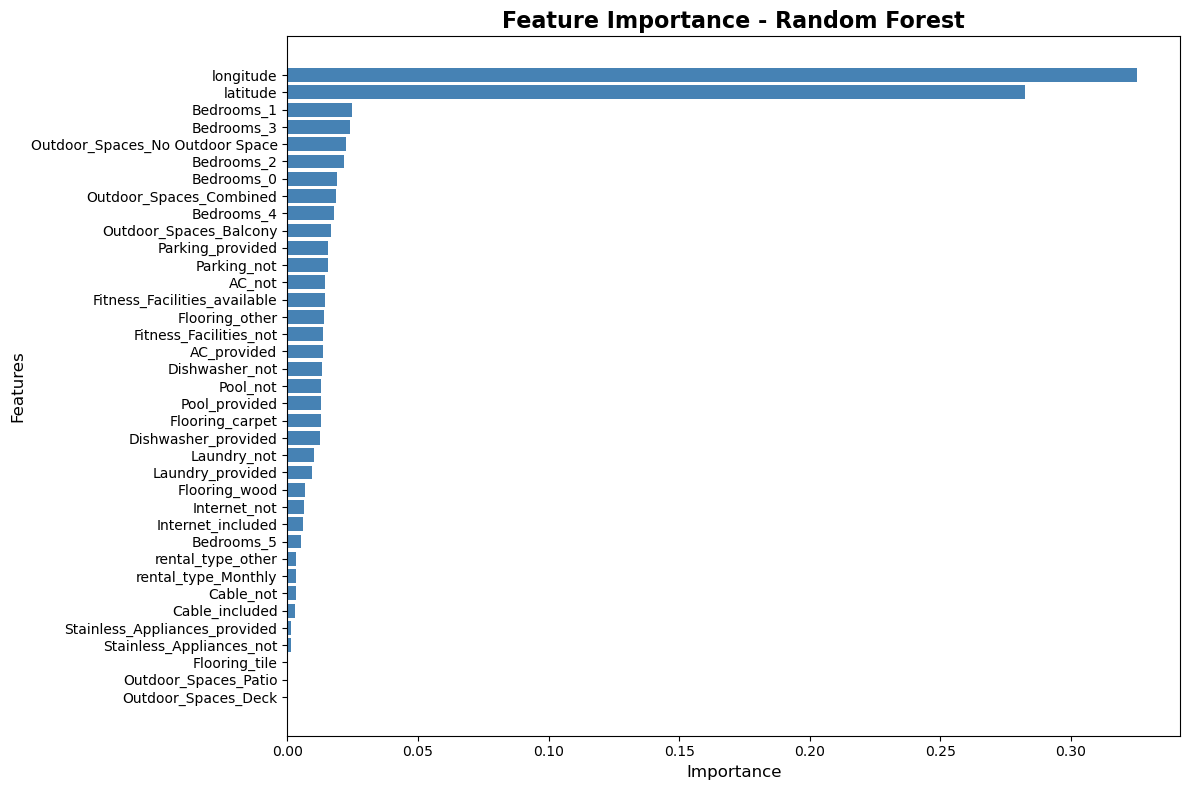


📊 Top 10 Most Important Features:
1. longitude: 0.3254
2. latitude: 0.2823
3. Bedrooms_1: 0.0249
4. Bedrooms_3: 0.0241
5. Outdoor_Spaces_No Outdoor Space: 0.0225
6. Bedrooms_2: 0.0219
7. Bedrooms_0: 0.0191
8. Outdoor_Spaces_Combined: 0.0188
9. Bedrooms_4: 0.0177
10. Outdoor_Spaces_Balcony: 0.0169


In [27]:
import matplotlib.pyplot as plt
import numpy as np
import shap

# Get the Random Forest model
rf_model = models["Random Forest"]

# ========================================
# 1. FEATURE IMPORTANCE PLOT
# ========================================
feature_importance = rf_model.feature_importances_
feature_names = X_train_encoded.columns if hasattr(X_train_encoded, 'columns') else [f'Feature {i}' for i in range(X_train_encoded.shape[1])]

# Sort features by importance
indices = np.argsort(feature_importance)[::-1]

# Plot feature importance
plt.figure(figsize=(12, 8))
plt.title("Feature Importance - Random Forest", fontsize=16, fontweight='bold')
plt.barh(range(len(indices)), feature_importance[indices], align='center', color='steelblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Print top 10 features
print("\n📊 Top 10 Most Important Features:")
for i in range(min(10, len(indices))):
    print(f"{i+1}. {feature_names[indices[i]]}: {feature_importance[indices[i]]:.4f}")


#### SHAP plot

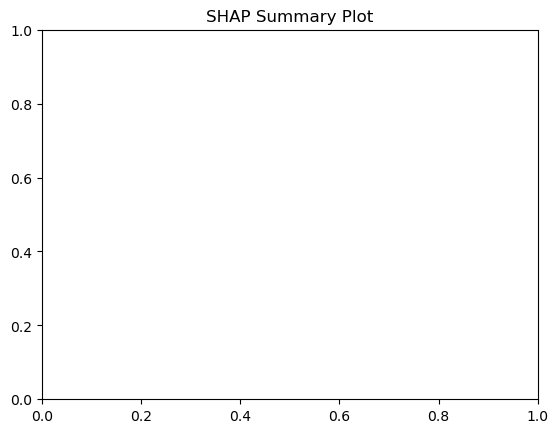

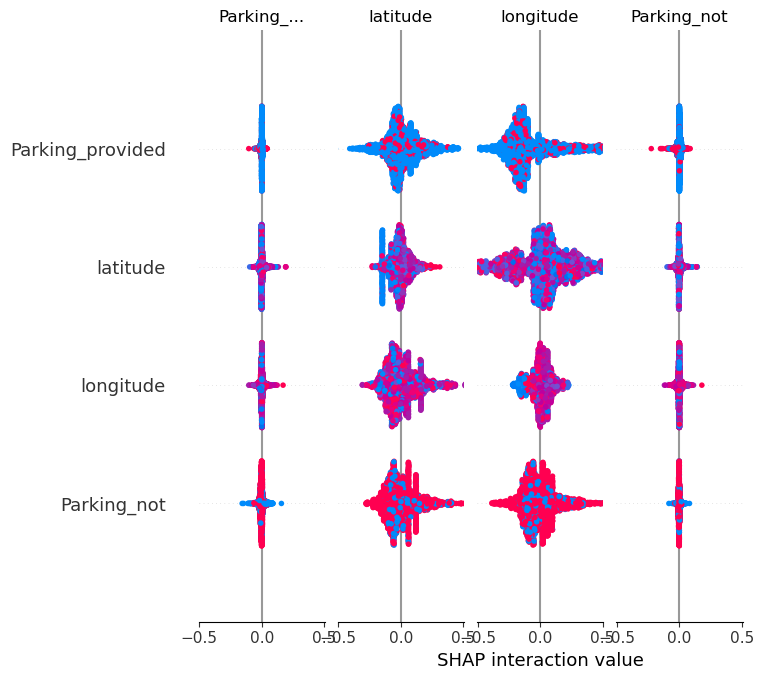

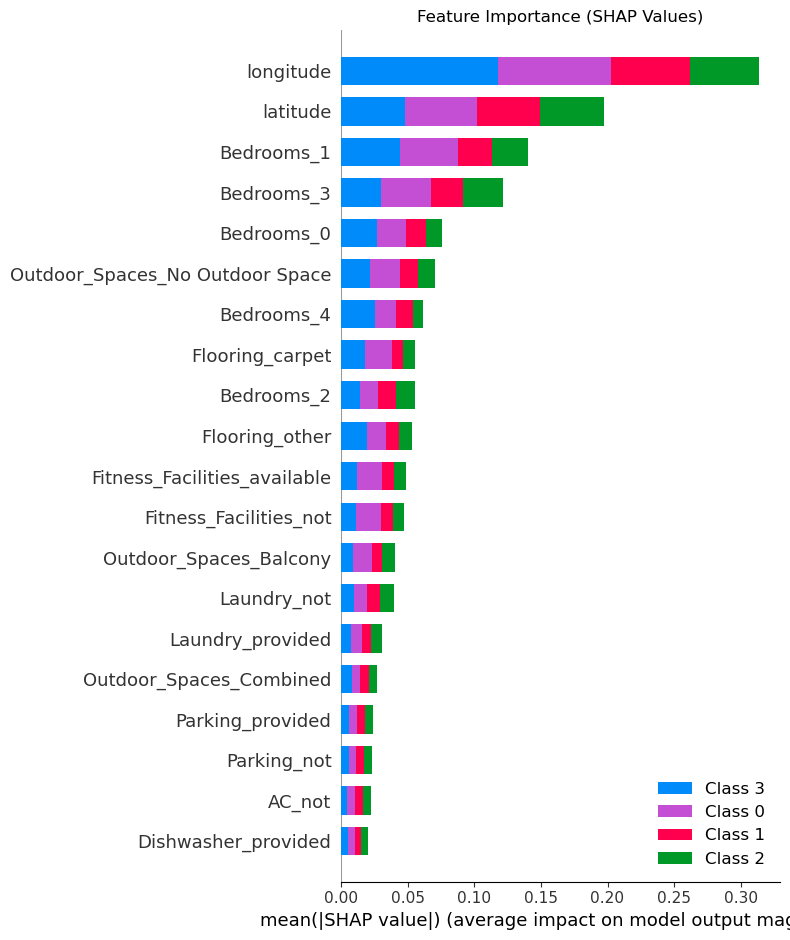

--- SHAP Dependence for Price Category 0 ---


IndexError: index 37 is out of bounds for axis 0 with size 37

In [28]:
# 1. Import libraries
import shap
import matplotlib.pyplot as plt

# 2. Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# 3. Calculate SHAP values
shap_values = explainer.shap_values(X_test_encoded)

# 4. Summary plot (global importance)
plt.title("SHAP Summary Plot")
shap.summary_plot(shap_values, X_test_encoded)
plt.show()

# 5. Bar plot (average absolute impact)
plt.title("Feature Importance (SHAP Values)")
shap.summary_plot(shap_values, X_test_encoded, plot_type="bar")
plt.show()

# 6. Dependence plot (for specific feature)
# To see how 'latitude' affects the prediction for Price_Category 0
print("--- SHAP Dependence for Price Category 0 ---")
shap.dependence_plot("latitude", shap_values[0], X_test_encoded, interaction_index="auto")
plt.show()

# To see how 'latitude' affects the prediction for Price_Category 1
print("\n--- SHAP Dependence for Price Category 1 ---")
shap.dependence_plot("latitude", shap_values[1], X_test_encoded, interaction_index="auto")
plt.show()

# To see how 'latitude' affects the prediction for Price_Category 2
print("\n--- SHAP Dependence for Price Category 2 ---")
shap.dependence_plot("latitude", shap_values[2], X_test_encoded, interaction_index="auto")
plt.show()

# To see how 'latitude' affects the prediction for Price_Category 3
print("\n--- SHAP Dependence for Price Category 3 ---")
shap.dependence_plot("latitude", shap_values[3], X_test_encoded, interaction_index="auto")
plt.show()

In [27]:
import joblib
import json

# --- Save the best model (Random Forest) ---
# We use joblib for efficient model saving
final_model = models["Random Forest"]
joblib.dump(final_model, 'house_price_model.pkl')

# --- Save the feature list from the one-hot encoded training data ---
# The app needs this exact list to create the input for prediction
model_feature_list = X_train_encoded.columns.tolist()
with open('model_features.json', 'w') as f:
    json.dump(model_feature_list, f)

print("✅ Model and feature list saved successfully!")
print(f"Total features the model expects: {len(model_feature_list)}")

✅ Model and feature list saved successfully!
Total features the model expects: 37


In [41]:
import json
import pandas as pd

# Load the original dataset again to get location data before cleaning
df_loc = pd.read_csv("geocoded_data_complete.csv")

# Drop rows where coordinates are missing, as they are unusable
df_loc.dropna(subset=['latitude', 'longitude', 'City', 'State'], inplace=True)

# Create a combined 'Location' column for the dropdown
df_loc['Location'] = df_loc['City'] + ", " + df_loc['State']

# Create a dictionary mapping the user-friendly location name to its coordinates
# We use drop_duplicates to ensure each location appears only once
locations_dict = df_loc.drop_duplicates(subset='Location').set_index('Location')[['latitude', 'longitude']].to_dict('index')

# Convert the dictionary values from {'latitude': x, 'longitude': y} to [x, y] for easier use
for loc, coords in locations_dict.items():
    locations_dict[loc] = [coords['latitude'], coords['longitude']]

# Save the dictionary to a JSON file
with open('locations.json', 'w') as f:
    json.dump(locations_dict, f, indent=4)

print(f"✅ 'locations.json' created successfully with {len(locations_dict)} unique locations.")

✅ 'locations.json' created successfully with 1481 unique locations.


In [42]:
data=pd.read_csv("geocoded_data_complete.csv")
data['City'].value_counts()

City
Austin           1356
San Antonio       435
Chicago           253
Madison           170
Portland          167
                 ... 
Klamath Falls       1
Laveen              1
Loomis              1
Morgan Hill         1
Chesterfield        1
Name: count, Length: 1353, dtype: int64